Dataset shape: (100, 8, 32, 32, 3)


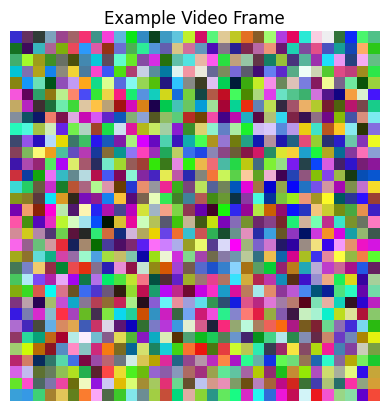

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

samples = 100
frames = 8
height = 32
width = 32
channels = 3
X = np.random.rand(samples, frames, height, width, channels)
print("Dataset shape:", X.shape)

frame = X[0,0]
plt.imshow(frame)
plt.title("Example Video Frame")
plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten,Dense

model = Sequential()
model.add(Conv3D(32, (3,3,3), activation='relu',
input_shape=(8,32,32,3)))
model.add(MaxPooling3D((2,2,2)))
model.add(Conv3D(64, (3,3,3), activation='relu'))
model.add(MaxPooling3D((2,2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 6, 30, 30, 32)  │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 3, 15, 15, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 1, 13, 13, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 0, 6, 6, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 0)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,499 (228.51 KB)

 Trainable params: 58,499 (228.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
y = np.random.randint(0,3,100)
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
history = model.fit(
X,
y,
epochs=5,
batch_size=8,
validation_split=0.2
)
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])
plt.show()

Epoch 1/5


ValueError: Exception encountered when calling MaxPooling3D.call().

[1mNegative dimension size caused by subtracting 2 from 1 for '{{node sequential_1/max_pooling3d_1_2/MaxPool3D}} = MaxPool3D[T=DT_FLOAT, data_format="NDHWC", ksize=[1, 2, 2, 2, 1], padding="VALID", strides=[1, 2, 2, 2, 1]](sequential_1/conv3d_1_2/Relu)' with input shapes: [8,1,13,13,64].[0m

Arguments received by MaxPooling3D.call():
  • inputs=tf.Tensor(shape=(8, 1, 13, 13, 64), dtype=float32)